# SLAM Crispness — Synthetic Drift Experiment Walkthrough

Interactive companion to [`reports/methods.md`](../reports/methods.md) and [`reports/results.md`](../reports/results.md).

We walk the full pipeline end to end:
**3D scene → timed trajectory → physically-grounded drift → corrupted map → 6 crispness metrics → evaluation**,
then load the automated experiment results and the scorecard.

Run top to bottom, or edit the parameters in the last section to explore.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import slam_synthbench as sb
from slam_synthbench import build_scene, make_trajectory, reference_cloud, observed_cloud, inject, LidarConfig
from slam_synthbench.metrics import compute_all, METRIC_INFO, REFERENCE_FREE
FIG = ROOT / 'figures'; RES = ROOT / 'experiments' / 'results'
print('scenes :', sb.SCENE_ORDER)
print('modes  :', sb.list_modes())
print('metrics:', list(METRIC_INFO))

scenes : ['room', 'parking', 'highway', 'corridor', 'tunnel']
modes  : ['sensor_noise', 'accel_bias', 'gyro_bias', 'dynamic_objects', 'geometric_degeneracy', 'weather_dropout', 'imu_saturation', 'random_walk', 'yaw_bias', 'range_scale', 'loop_closure_seam', 'sinusoidal', 'step_jump', 'gyro_saturation', 'imu_consumer', 'imu_industrial', 'imu_tactical', 'imu_navigation']
metrics: ['voxel_pca_crispness', 'mme_grid', 'mom_planarity', 'bev_edge_density', 'knn_entropy_mme', 'chamfer_oracle']


## 1. Build a scene and look at the ideal map

A scene is a set of 3D planar quads; a LiDAR is driven over a timed trajectory and
sweeps are accumulated into the **reference** (ideal, noise-free) cloud.

room: 12 surfaces, 200 poses, 20s, 691,200 ref points


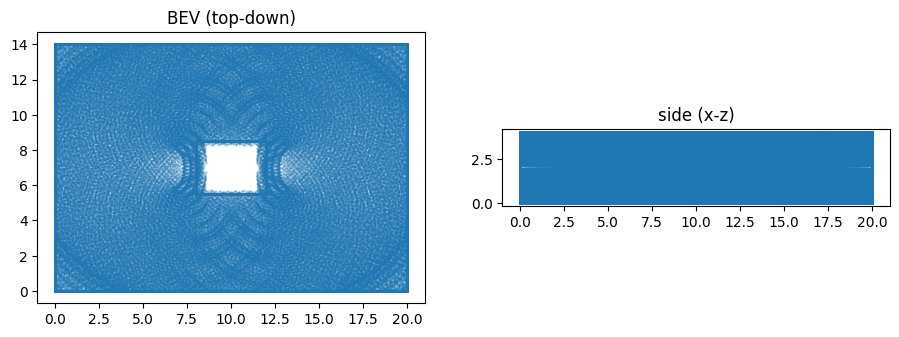

In [2]:
cfg = LidarConfig(n_beams=24, azimuth_step_deg=2.5)
scene = build_scene('room')
traj = make_trajectory(scene, duration=20.0)
ref = reference_cloud(scene, traj, cfg)
print(f'{scene.name}: {scene.n_surfaces()} surfaces, {traj.n} poses, {traj.duration:.0f}s, {len(ref):,} ref points')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(ref[:,0], ref[:,1], s=0.3, alpha=0.3); ax[0].set_title('BEV (top-down)'); ax[0].set_aspect('equal')
ax[1].scatter(ref[:,0], ref[:,2], s=0.3, alpha=0.3); ax[1].set_title('side (x-z)'); ax[1].set_aspect('equal')
plt.show()

## 2. Inject drift and compare observed vs reference

The observed cloud re-projects true observations through the **drifted** estimated
poses — correct points placed by a wrong trajectory. Try changing `mode`/`level`.

gyro_bias @ level 0.8: tier=bias, RMS pose error = 0.392 m, realized={'b_g_rad_s': 8e-05, 'b_g_dph': np.float64(16.50118449976771)}


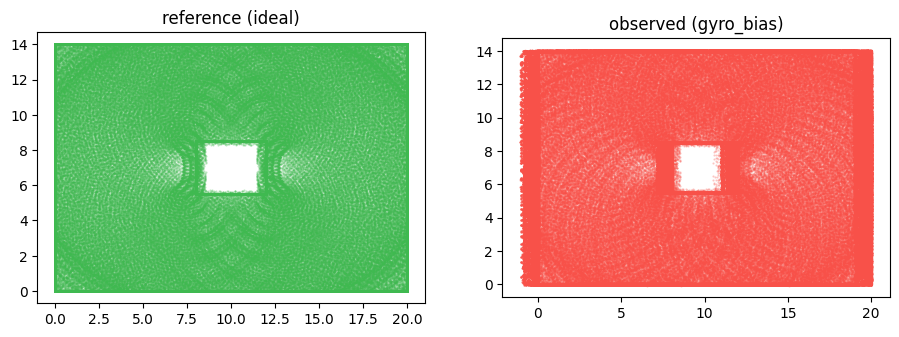

In [3]:
mode, level = 'gyro_bias', 0.8
dr = inject(traj, scene, mode, level, seed=0)
obs = observed_cloud(scene, traj, dr, cfg, seed=0)
print(f'{mode} @ level {level}: tier={dr.tier}, RMS pose error = {dr.drift_intensity:.3f} m, realized={dr.realized}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(ref[:,0], ref[:,1], s=0.3, c='#3fb950', alpha=0.3); ax[0].set_title('reference (ideal)')
ax[1].scatter(obs[:,0], obs[:,1], s=0.3, c='#f85149', alpha=0.3); ax[1].set_title(f'observed ({mode})')
for a in ax: a.set_aspect('equal')
plt.show()

## 3. Score one sample with all six metrics

In [4]:
scores = compute_all(obs, ref, voxel=0.5)
pd.DataFrame({'score': scores, 'higher_is_better': {k: METRIC_INFO[k].higher_is_better for k in scores},
              'complexity': {k: METRIC_INFO[k].complexity for k in scores}})

,score,higher_is_better,complexity
voxel_pca_crispness,0.876076,True,O(N)
mme_grid,0.447773,True,O(N)
mom_planarity,0.730819,True,O(N)
bev_edge_density,0.203789,True,O(N)
knn_entropy_mme,22.639304,True,O(N log N)
chamfer_oracle,0.182071,False,O(N log N)


## 4. Mini sensitivity sweep — which metric tracks the drift?

Sweep `gyro_bias` severity and watch each (min-max normalized) metric fall as the
chamfer oracle (true drift) rises.

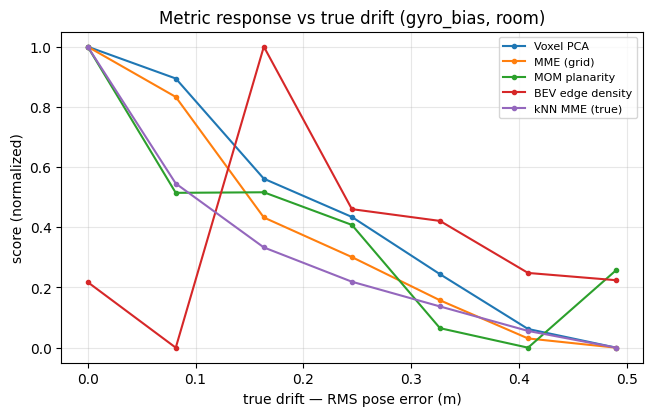

,level,drift_m,voxel_pca_crispness,mme_grid,mom_planarity,bev_edge_density,knn_entropy_mme,chamfer_oracle
0,0.000,0.000,0.985,0.828,0.864,0.200,24.306,0.143
1,0.167,0.082,0.973,0.763,0.800,0.191,23.494,0.150
2,0.333,0.163,0.934,0.605,0.800,0.233,23.115,0.159
3,0.500,0.245,0.920,0.553,0.786,0.210,22.912,0.167
4,0.667,0.327,0.898,0.497,0.740,0.209,22.765,0.175
5,0.833,0.408,0.877,0.447,0.731,0.201,22.620,0.184
6,1.000,0.490,0.870,0.435,0.765,0.200,22.521,0.192


In [5]:
rows = []
for lvl in np.linspace(0, 1, 7):
    s = sb.make_sample('room', 'gyro_bias', float(lvl), seed=0, cfg=cfg, duration=20.0, ref=ref)
    rows.append({'level': lvl, 'drift_m': s.drift_intensity, **s.scores})
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
for k in REFERENCE_FREE:
    y = sweep[k].values; y = (y - y.min())/(y.max()-y.min()+1e-9)
    ax.plot(sweep['drift_m'], y, '-o', ms=3, label=METRIC_INFO[k].label)
ax.set_xlabel('true drift — RMS pose error (m)'); ax.set_ylabel('score (normalized)')
ax.set_title('Metric response vs true drift (gyro_bias, room)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()
sweep.round(3)

## 5. The degeneracy blind-spot — tunnel vs room

In a tunnel, along-axis drift slides points *along* the wall, so the surface stays
locally planar and voxel-PCA barely notices — even as the oracle shows large true
error. Compare the same `gyro_bias` in both scenes.

In [6]:
comp = []
for sc in ['room', 'tunnel']:
    for lvl in [0.0, 0.5, 1.0]:
        s = sb.make_sample(sc, 'gyro_bias', lvl, seed=0, cfg=cfg, duration=20.0)
        comp.append({'scene': sc, 'level': lvl, 'drift_m': round(s.drift_intensity,3),
                     'voxel_pca': round(s.scores['voxel_pca_crispness'],3),
                     'chamfer': round(s.scores['chamfer_oracle'],3)})
pd.DataFrame(comp)

,scene,level,drift_m,voxel_pca,chamfer
0,room,0.0,0.000,0.985,0.143
1,room,0.5,0.245,0.920,0.167
2,room,1.0,0.490,0.870,0.192
3,tunnel,0.0,0.000,0.985,0.198
4,tunnel,0.5,0.245,0.964,0.277
5,tunnel,1.0,0.490,0.933,0.382


## 6. Load the automated experiment results & scorecard

Run `python experiments/run_all.py` first to (re)generate these.

,sensitivity,oracle_agreement,separability,noise_robustness,scene_independence,compute_ms,exponent,compute_score
voxel_pca_crispness,0.770,0.541,0.813,0.976,0.992,213.946,1.070,0.001
mme_grid,0.798,0.611,0.770,0.862,0.901,216.429,1.065,0.000
mom_planarity,0.673,0.571,0.849,1.000,0.951,213.786,1.066,0.001
bev_edge_density,0.192,0.227,0.490,1.000,0.549,9.164,0.885,1.000
knn_entropy_mme,0.975,0.922,0.892,0.896,0.950,80.071,0.553,0.082


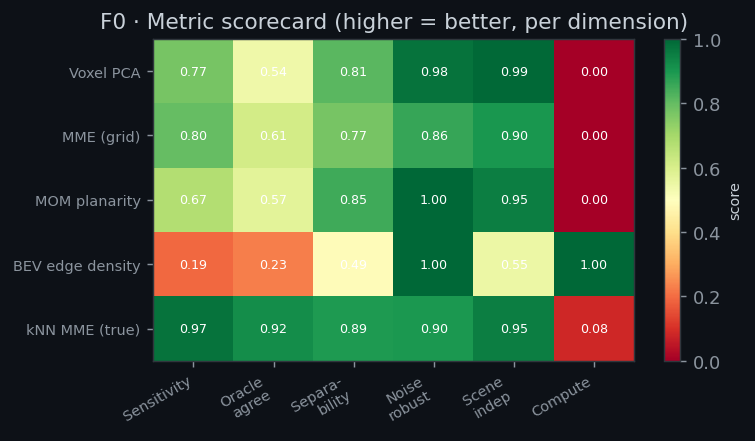

In [7]:
if (RES / 'scorecard.csv').exists():
    sc = pd.read_csv(RES / 'scorecard.csv', index_col=0)
    display(sc.round(3))
    display(Image(filename=str(FIG / 'f0_scorecard.png')))
else:
    print('No scorecard yet — run experiments/run_all.py')

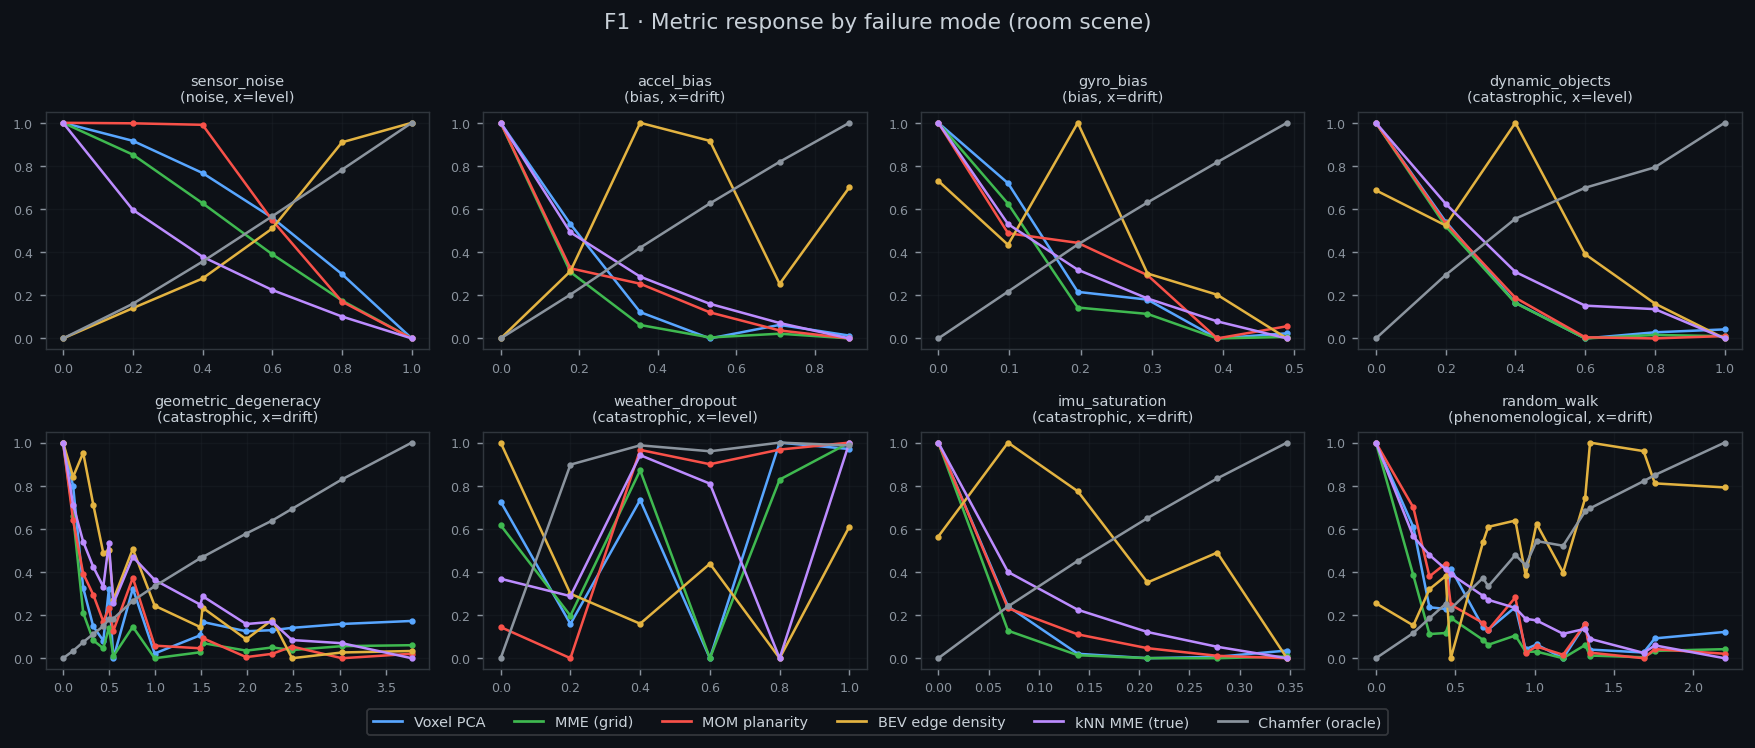

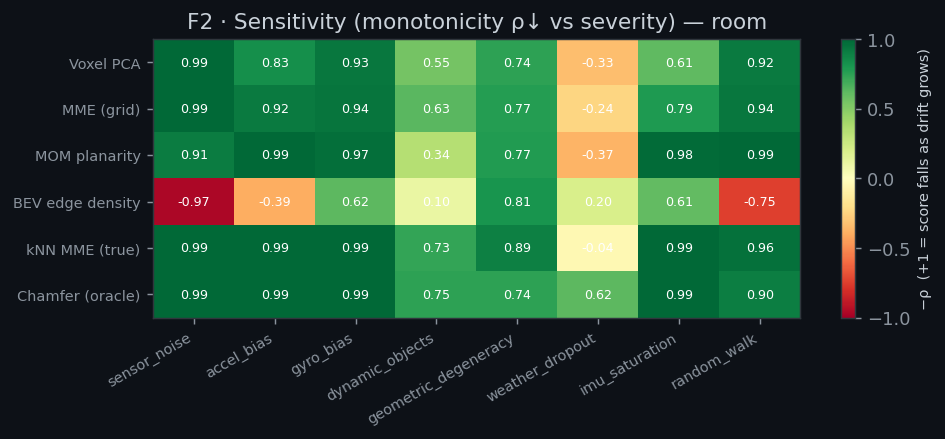

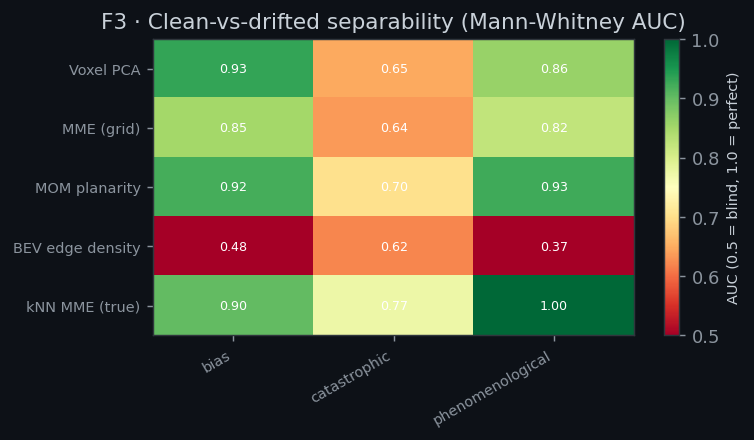

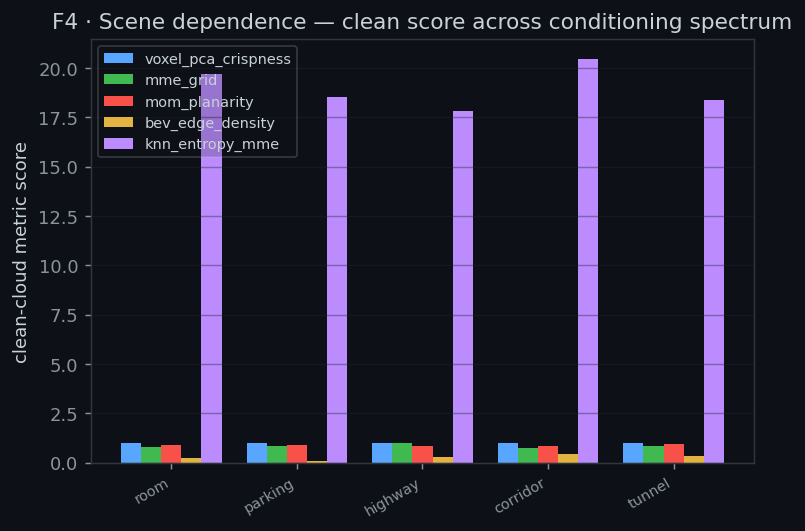

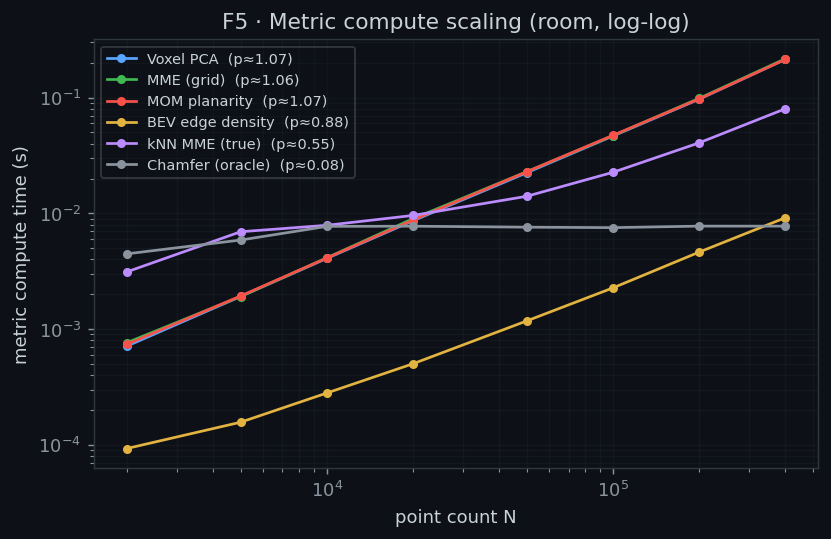

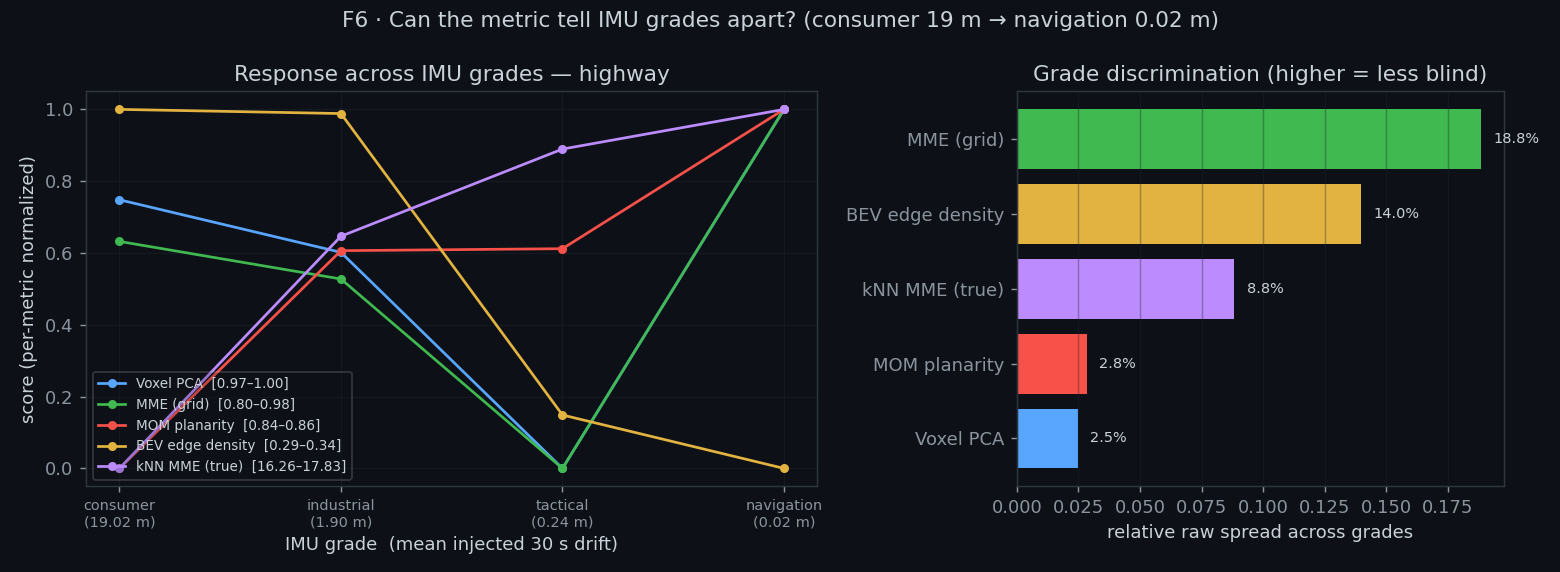

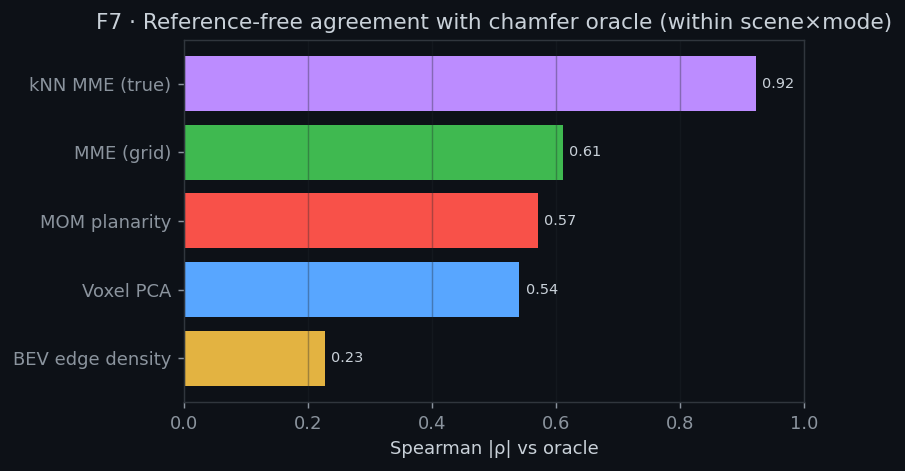

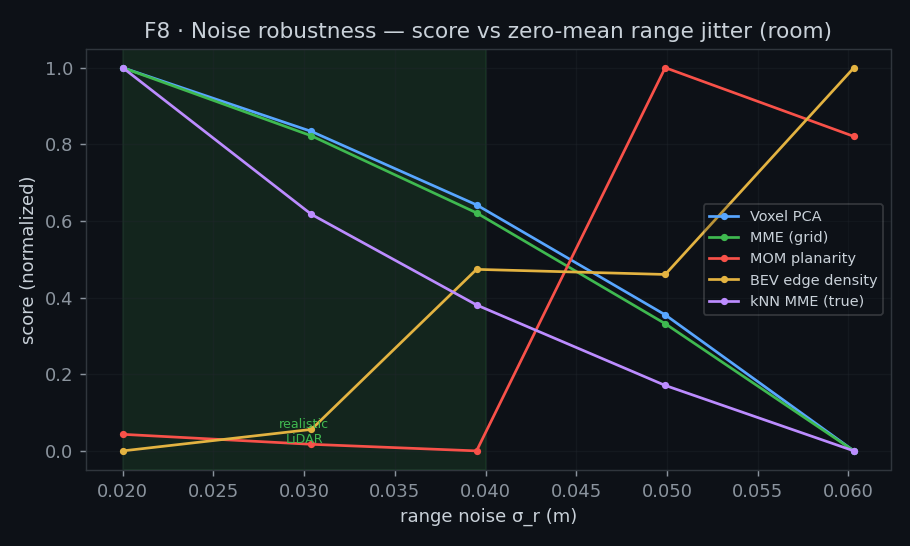

In [8]:
for f in ['f1_sensitivity_grid', 'f2_monotonicity_heatmap', 'f3_tier_separability',
          'f4_scene_dependence', 'f5_compute_complexity', 'f6_imu_grade',
          'f7_oracle_correlation', 'f8_noise_robustness']:
    p = FIG / f'{f}.png'
    if p.exists():
        display(Image(filename=str(p)))

## 7. Your turn

Change the parameters and re-run. Some prompts:
- Set `MODE='dynamic_objects'` — do the reference-free metrics even notice ghost trails?
- Set `SCENE='tunnel'`, `MODE='geometric_degeneracy'` — watch the oracle move while voxel-PCA stays flat.
- Raise `cfg.range_noise_sigma` to 0.1 — which metrics are fooled by benign noise?

tunnel / geometric_degeneracy @ 0.7: tier=catastrophic, drift=2.651 m, N=670,090


voxel_pca_crispness     0.981
mme_grid                0.785
mom_planarity           0.936
bev_edge_density        0.301
knn_entropy_mme        21.763
chamfer_oracle          0.214
dtype: float64

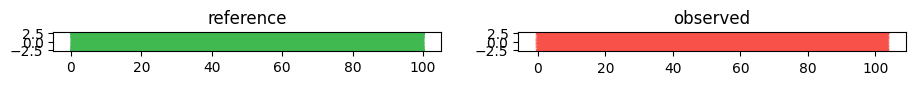

In [9]:
SCENE, MODE, LEVEL, SEED = 'tunnel', 'geometric_degeneracy', 0.7, 0
s = sb.make_sample(SCENE, MODE, LEVEL, seed=SEED, cfg=cfg, duration=20.0, keep_clouds=True)
print(f'{SCENE} / {MODE} @ {LEVEL}: tier={s.tier}, drift={s.drift_intensity:.3f} m, N={s.n_points:,}')
display(pd.Series(s.scores).round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(s.reference[:,0], s.reference[:,1], s=0.3, c='#3fb950', alpha=0.3); ax[0].set_title('reference')
ax[1].scatter(s.observed[:,0], s.observed[:,1], s=0.3, c='#f85149', alpha=0.3); ax[1].set_title('observed')
for a in ax: a.set_aspect('equal')
plt.show()